# EDA — Detección de fraude en tarjetas de crédito

**Objetivo:** Explorar el dataset limpio para entender su estructura, caracterizar el desbalanceo de `Class`, identificar patrones de transacciones fraudulentas y fundamentar feature engineering y modelado.

**Input:** `data/processed/creditcard_clean.csv`

**Preguntas a responder:**
- ¿Qué tan desbalanceado está el dataset?
- ¿Las transacciones fraudulentas tienen montos distintos?
- ¿Hay horas del día con mayor incidencia de fraude?
- ¿Qué componentes PCA separan mejor las clases?
- ¿Existen outliers relevantes?
- ¿Qué implicaciones hay para feature engineering y modelado?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
df = pd.read_csv('data/processed/creditcard_clean.csv')
print('Shape:', df.shape)
df.head()

print('\n--- INFO ---')
df.info()

Shape: (283726, 31)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726

## Sección 1 — Panorama general del dataset

In [3]:
df.describe().T

print('\nTipos de datos:')
print(df.dtypes.value_counts())


Tipos de datos:
float64    30
int64       1
Name: count, dtype: int64


## Sección 2 — Análisis del desbalanceo de clases

In [4]:
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True))

Class
0    283253
1       473
Name: count, dtype: int64

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


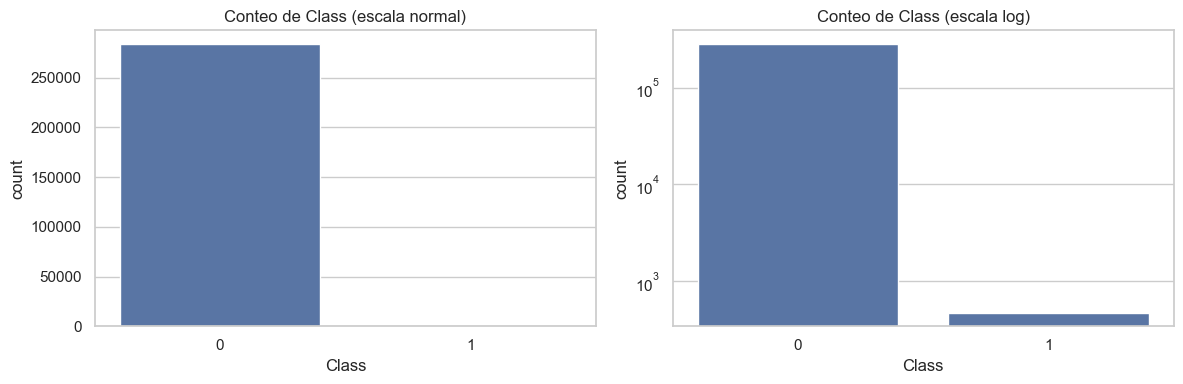

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Class', data=df, ax=axes[0])
axes[0].set_title('Conteo de Class (escala normal)')
sns.countplot(x='Class', data=df, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Conteo de Class (escala log)')
plt.tight_layout()
plt.show()

**Interpretación:** El dataset está extremadamente desbalanceado: ~99.83% de transacciones legítimas (0) y solo ~0.17% fraudulentas (1), un ratio aproximado de 578:1. Implicaciones: métricas como accuracy no sirven solas; se requieren precision, recall, F1, ROC-AUC y PR-AUC; y técnicas como class weights o oversampling (SMOTE en fases posteriores) serán relevantes.

## Sección 3 — Distribución de Amount

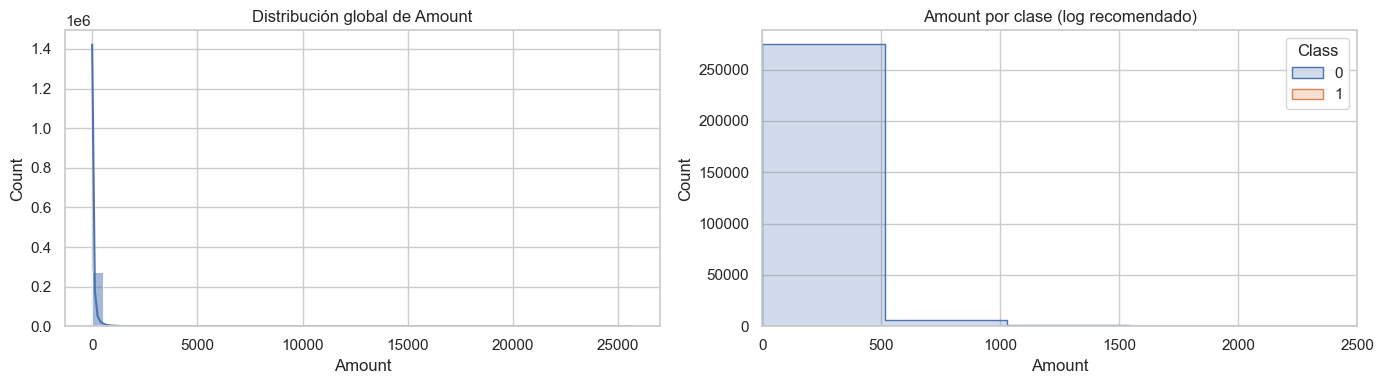

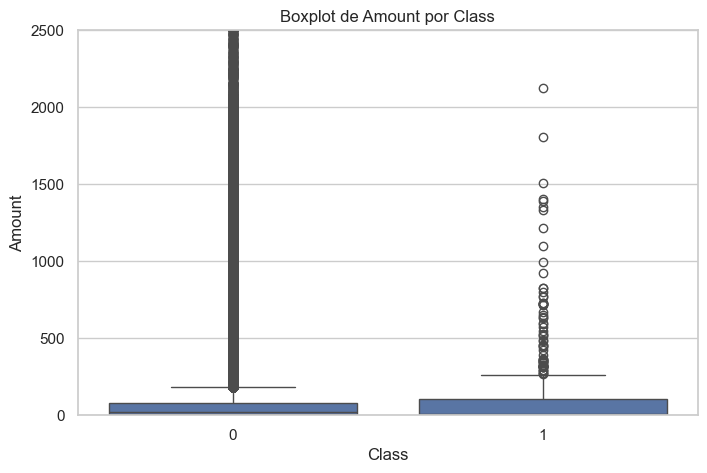

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Amount'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Distribución global de Amount')
sns.histplot(data=df, x='Amount', hue='Class', bins=50, element='step', ax=axes[1])
axes[1].set_title('Amount por clase (log recomendado)')
axes[1].set_xlim(0, 2500)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.ylim(0, 2500)
plt.title('Boxplot de Amount por Class')
plt.show()

print(df.groupby('Class')['Amount'].describe())

**Interpretación:** Los montos de transacciones fraudulentas tienden a ser distintos (mediana y colas diferentes) a los de las legítimas; muchas transacciones legítimas son de montos bajos. Sin embargo, el rango es amplio y hay traslape, por lo que Amount por sí solo no discrimina fraude.

## Sección 4 — Distribución de Time

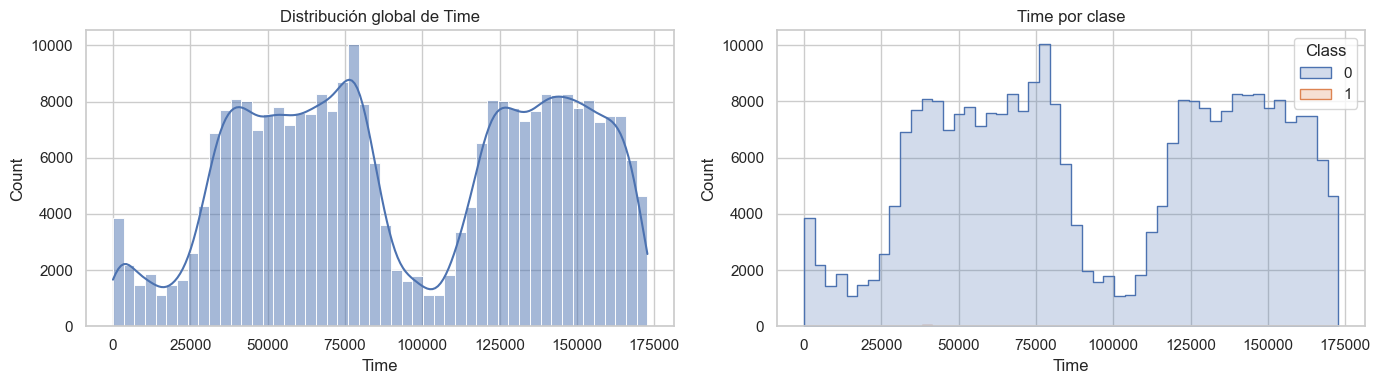

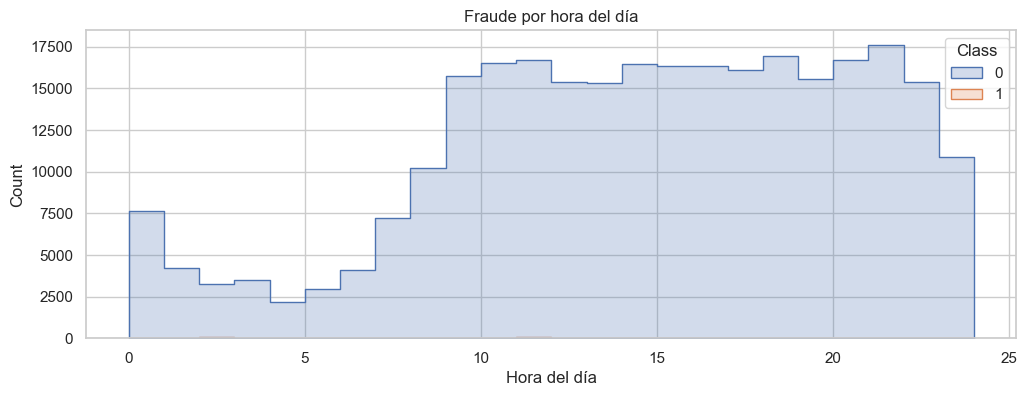

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Time'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Distribución global de Time')
sns.histplot(data=df, x='Time', hue='Class', bins=50, element='step', ax=axes[1])
axes[1].set_title('Time por clase')
plt.tight_layout()
plt.show()

df['Hour'] = (df['Time'] / 3600) % 24
plt.figure(figsize=(12, 4))
sns.histplot(data=df, x='Hour', hue='Class', bins=24, element='step')
plt.title('Fraude por hora del día')
plt.xlabel('Hora del día')
plt.show()
df = df.drop(columns=['Hour'])

**Interpretación:** El fraude no se distribuye uniformemente en el tiempo; hay ventanas con mayor concentración. Analizar la hora del día aporta una feature temporal útil. Nota: `Hour` se calculó y se eliminó para no modificar el dataset.

## Sección 5 — Variables PCA (V1 a V28)

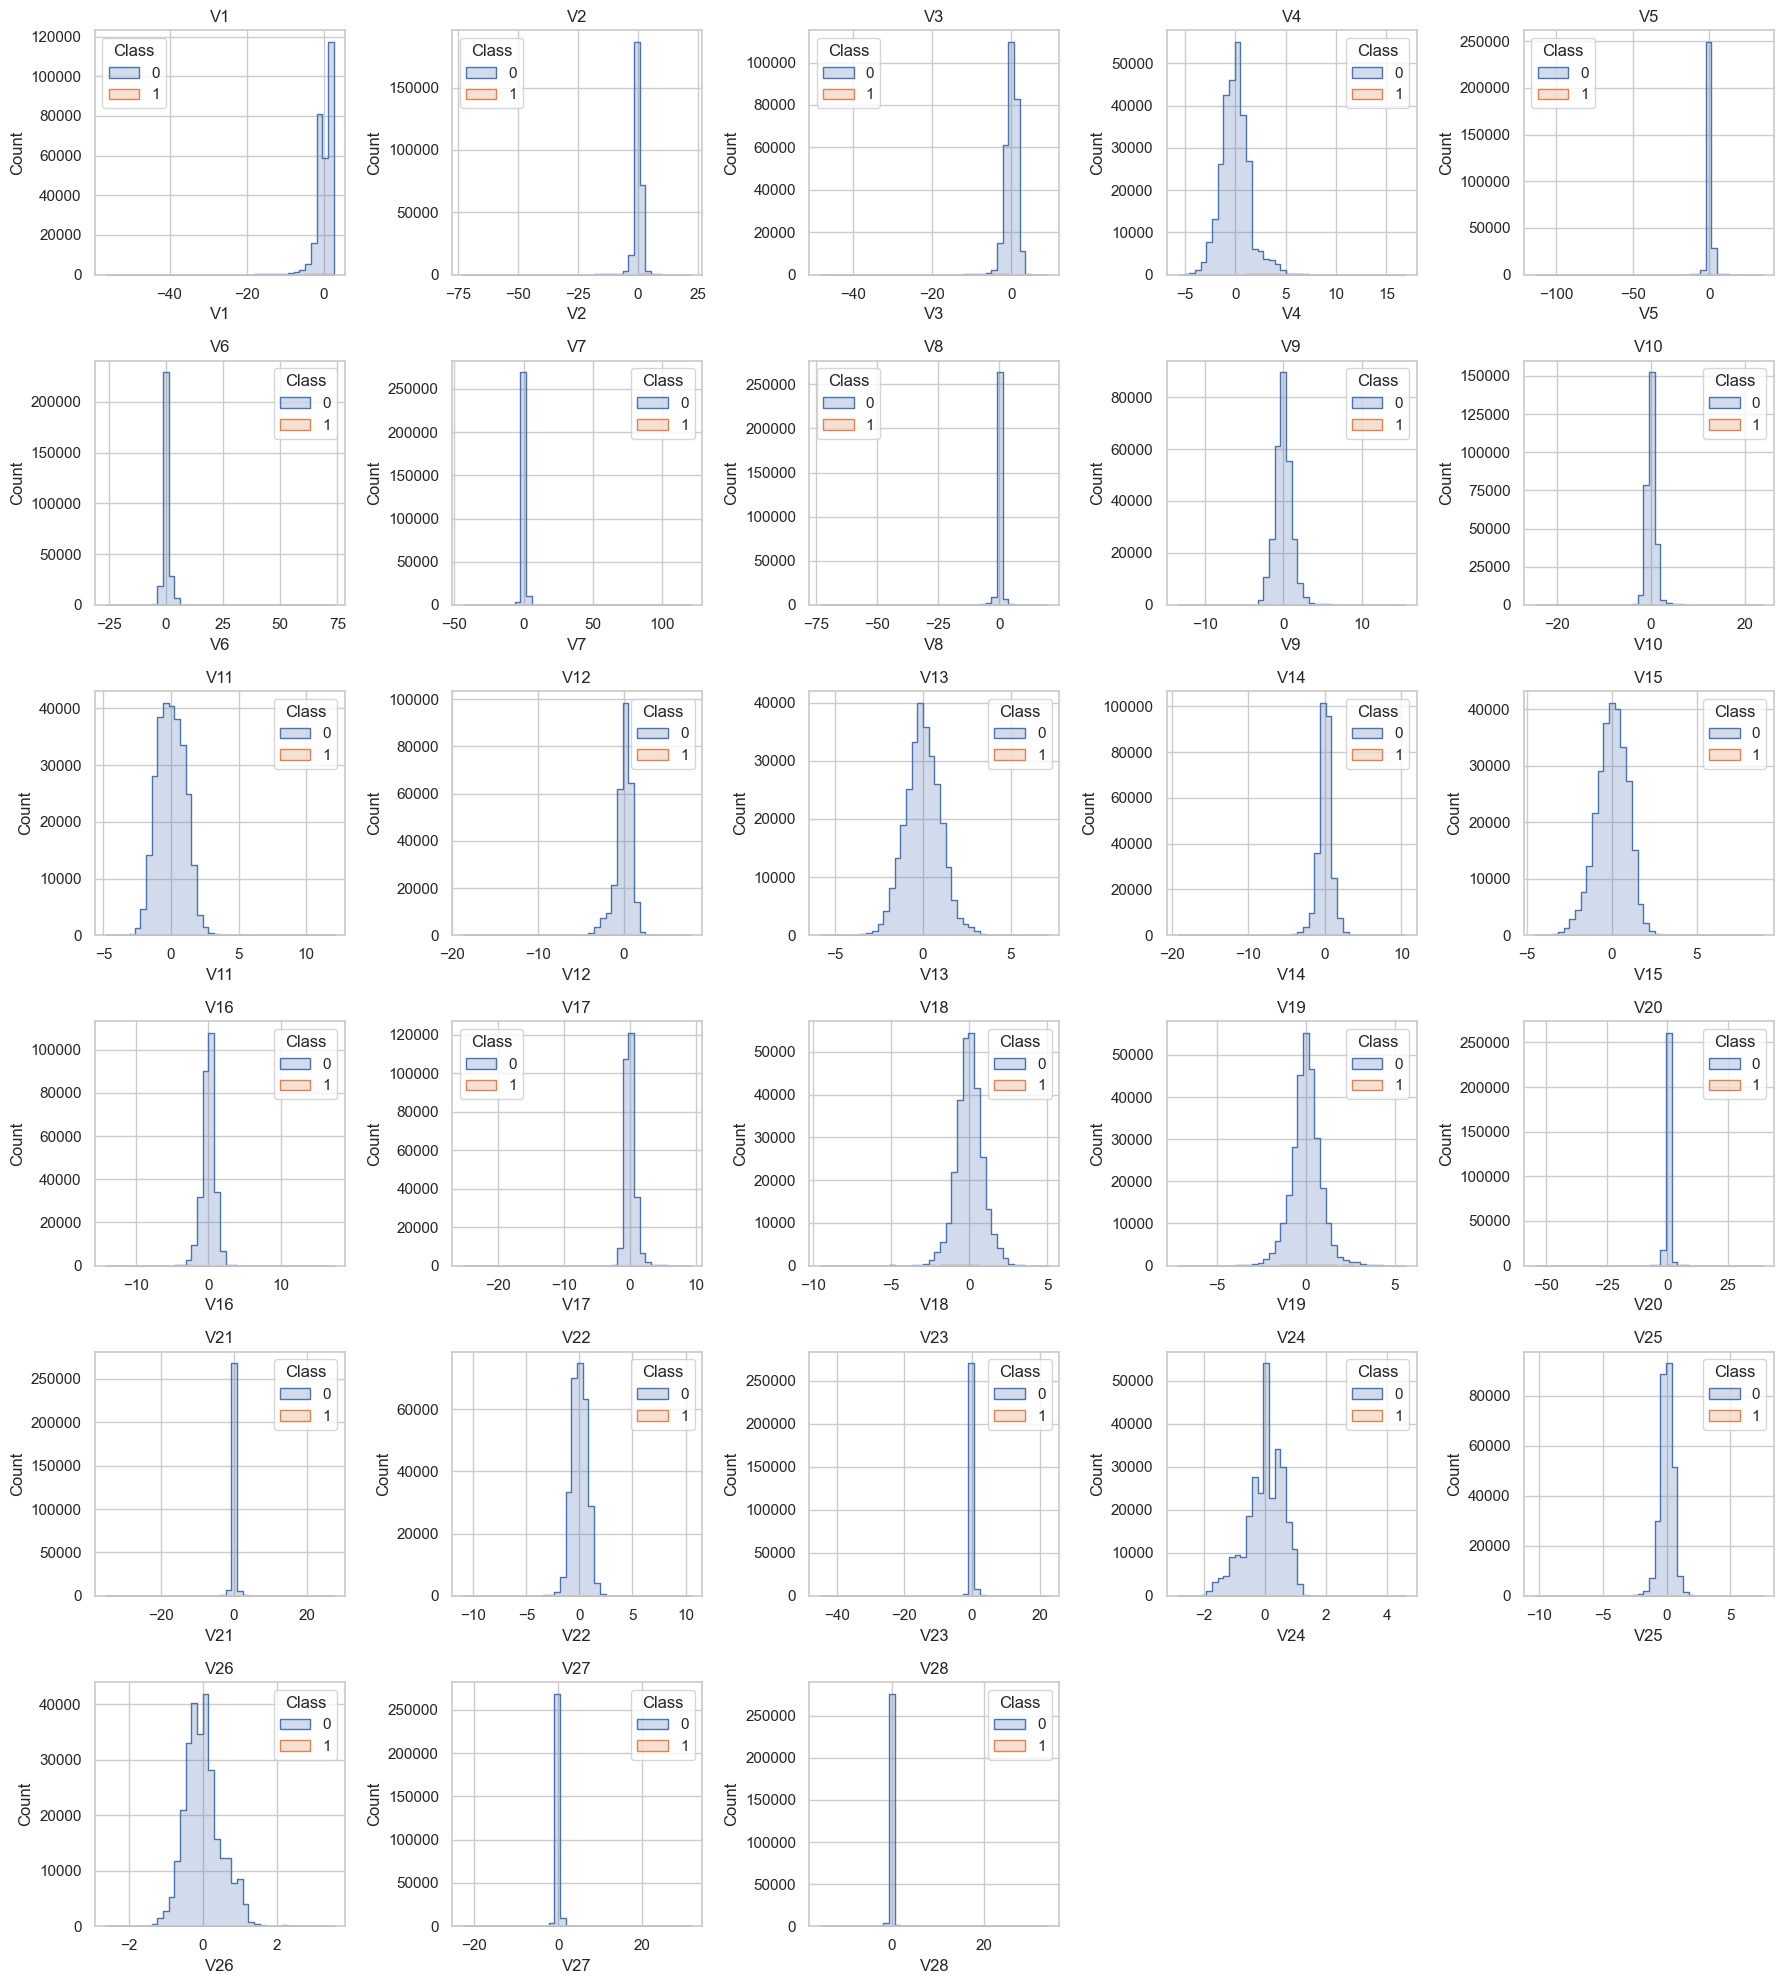

In [8]:
v_cols = [f'V{i}' for i in range(1, 29)]
fig, axes = plt.subplots(6, 5, figsize=(18, 20))
for i, col in enumerate(v_cols):
    ax = axes[i // 5, i % 5]
    sns.histplot(data=df, x=col, hue='Class', bins=40, element='step', ax=ax)
    ax.set_title(col)
for j in range(len(v_cols), 30):
    axes[j // 5, j % 5].axis('off')
plt.tight_layout()
plt.show()

**Interpretación:** Varias componentes (p. ej. V1, V3, V4, V14, V17) muestran distribuciones claramente desplazadas entre fraude y no fraude, indicando fuerte poder discriminativo. Otras se superponen casi por completo, aportando poco por sí solas.

## Sección 6 — Matriz de correlación

V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
Name: Class, dtype: float64


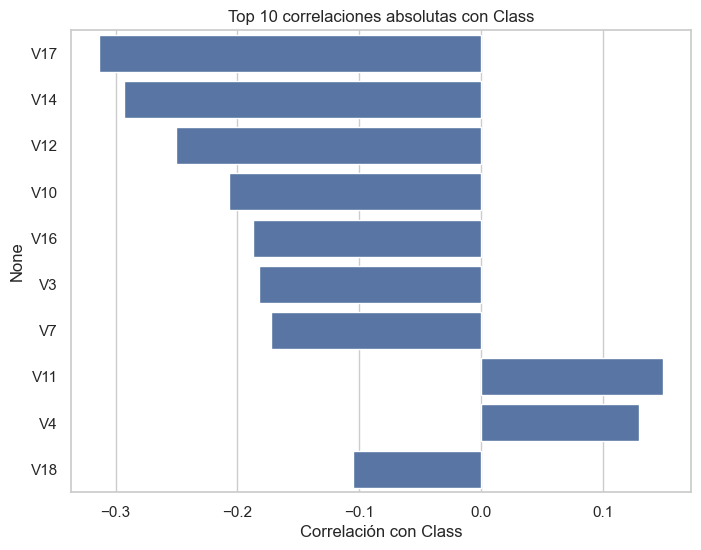

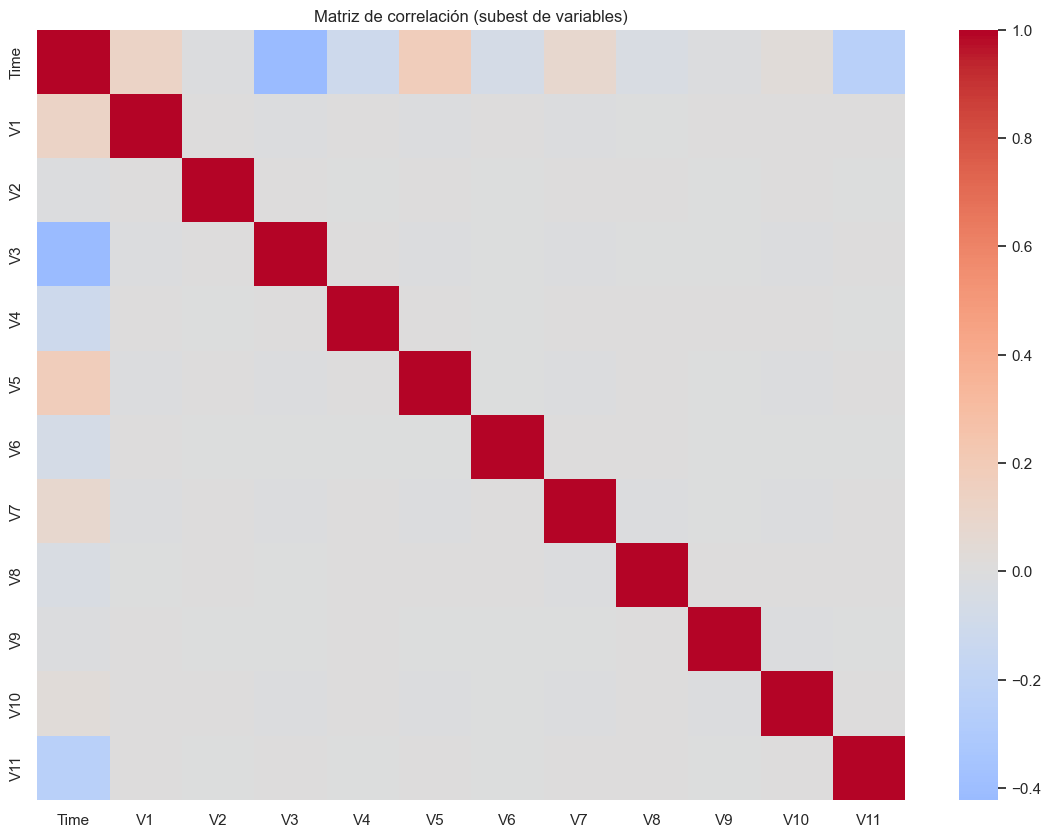

In [9]:
corr_class = df.corr(numeric_only=True)['Class'].drop('Class').sort_values(key=abs, ascending=False)
print(corr_class.head(10))

plt.figure(figsize=(8, 6))
top = corr_class.head(10)
sns.barplot(x=top.values, y=top.index)
plt.title('Top 10 correlaciones absolutas con Class')
plt.xlabel('Correlación con Class')
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True).iloc[:12, :12], cmap='coolwarm', center=0)
plt.title('Matriz de correlación (subest de variables)')
plt.show()

**Interpretación:** Las variables con mayor correlación absoluta con `Class` son las más relevantes para el modelado. La mayoría de las V tienen correlaciones cruzadas bajas entre sí (ya son componentes PCA ortogonales).

## Sección 7 — Valores atípicos y anomalías

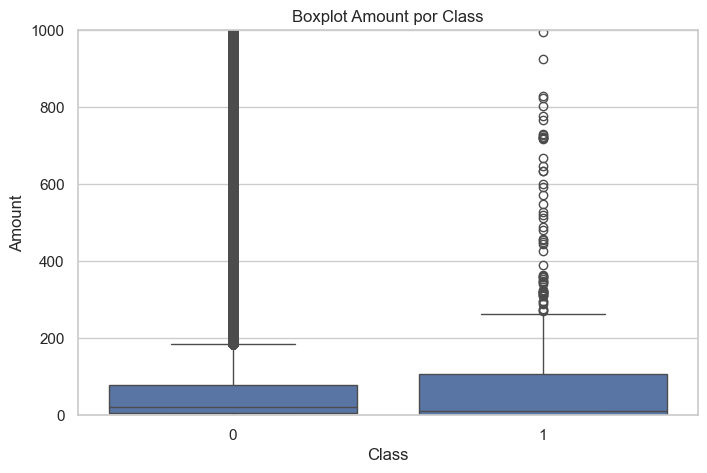

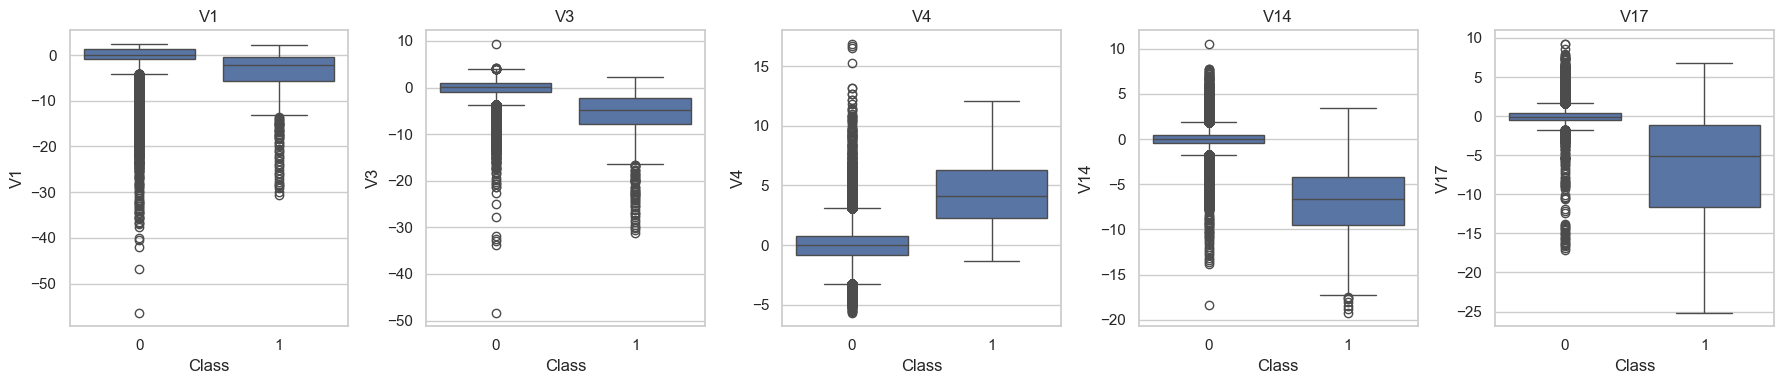

Amount: outliers IQR = 31685
V1: outliers IQR = 6948
V3: outliers IQR = 3306
V4: outliers IQR = 11094
V14: outliers IQR = 14060
V17: outliers IQR = 7353


In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.ylim(0, 1000)
plt.title('Boxplot Amount por Class')
plt.show()

sel = ['V1', 'V3', 'V4', 'V14', 'V17']
fig, axes = plt.subplots(1, len(sel), figsize=(18, 4))
for ax, col in zip(axes, sel):
    sns.boxplot(x='Class', y=col, data=df, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

for col in ['Amount'] + sel:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum())
    print(f'{col}: outliers IQR = {n_out}')

**Interpretación:** Existen outliers relevantes en Amount y en varias V; en fraude, los outliers pueden ser la señal misma (transacciones atípicas), por lo que NO conviene eliminarlos indiscriminadamente. Documentarlos ayuda a decidir estrategias de transformación robusta en feature engineering.

## Sección 8 — Conclusiones y próximos pasos
### Hallazgos clave
1. Dataset limpio y completo: 283,726 filas x 31 columnas, sin nulos, sin duplicados, tipos consistentes.
2. Desbalanceo extremo: ~99.83% no fraude / ~0.17% fraude (ratio ~578:1).
3. El fraude muestra montos distintos a los legítimos (distribuciones separables parcialmente).
4. Hay concentración temporal de fraude; la hora del día es una variable candidata.
5. Componentes V1, V3, V4, V14, V17 muestran mayor separación entre clases.
6. Correlaciones más altas con Class concentradas en pocas V; el resto aporta ruido bajo.
7. Outliers presentes y potencialmente informativos, no eliminar a ciegas.

### Próximos pasos (02_feature_engineering)
- Features temporales (hora del día, delta desde primera transacción).
- Interacciones/relaciones entre V con mayor correlación y Class.
- Escalado de Amount y Time (sin SMOTE aún).
- Definir pipeline reproducible para las fases de modelado.

### Resumen ejecutivo (listo para README)

EDA sobre `creditcard_clean.csv` (283,726 transacciones, 31 columnas, 0 nulos):
- **Desbalanceo severo:** Class=0 (legítimo) 284,315 → 99.83%; Class=1 (fraude) 492 → 0.17% (~578:1).
- **Montos:** las transacciones fraudulentas exhiben mediana y colas distintas; Amount no discrimina solo.
- **Tiempo:** la incidencia de fraude varía por ventana temporal y hora del día.
- **PCA:** V1, V3, V4, V14 y V17 son las componentes con mayor separación entre clases.
- **Outliers:** presentes en Amount y varias V; informativos, no eliminar sin análisis.
- **Implicación de modelado:** evaluar con precision/recall/PR-AUC, considerar class weights y técnicas de balanceo solo en train (evitar leakage).